# CS3807 – Deep Learning Laboratory
## Experiment: Evolution of CNN Architectures & Transfer Learning on CIFAR-10

**Aim:** Compare LeNet-5, AlexNet, VGG16, GoogLeNet (InceptionV3), and ResNet50 on CIFAR-10, using
transfer learning for the pretrained models, and evaluate all five with standard classification metrics.

**Why this version runs fast (previous version took 1hr+ per model and one got stuck):**
- Uses a **stratified-random subset** of CIFAR-10 (4000 train / 800 test) instead of the full 50k/10k images —
  more than enough to demonstrate architectural differences for a lab, not enough to take an hour per model.
- Uses **`tf.data`** pipelines (`.map → .batch → .cache → .prefetch`) instead of `ImageDataGenerator.flow()`.
  `flow()` is an infinite generator — if `steps_per_epoch` isn't set explicitly it can hang forever, which is
  almost certainly what got "stuck" last time. `tf.data` datasets here are finite, so `model.fit` just stops
  naturally at the end of each epoch.
- Resizes images to the **minimum input size each architecture actually requires** (32 for LeNet/VGG/ResNet,
  64 for the scaled AlexNet, 75 for InceptionV3) instead of blowing every image up to 224×224.
- **Freezes** the pretrained base (`base_model.trainable = False`) so only a small head is trained —
  this is standard feature-extraction transfer learning and is dramatically cheaper than full fine-tuning.
- Adds `EarlyStopping` and calls `keras.backend.clear_session()` between models to free GPU/CPU memory.

On a Colab GPU runtime, all 5 models together should finish in well under 15 minutes. On CPU it will be slower
but should still complete (tens of minutes, not hours). If you want higher accuracy afterwards, just increase
`N_TRAIN` / epochs once you've confirmed everything runs end-to-end.

## 1. Setup & Imports

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import VGG16, InceptionV3, ResNet50
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPU available:", bool(gpus), gpus)
if not gpus:
    print("\nTip: Runtime > Change runtime type > GPU (T4) will make this notebook run much faster.")

tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version: 2.20.0
GPU available: True [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Load CIFAR-10 & Take a Fast, Representative Subset

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2022s 12us/step
Train subset: (4000, 32, 32, 3), Test subset: (800, 32, 32, 3)


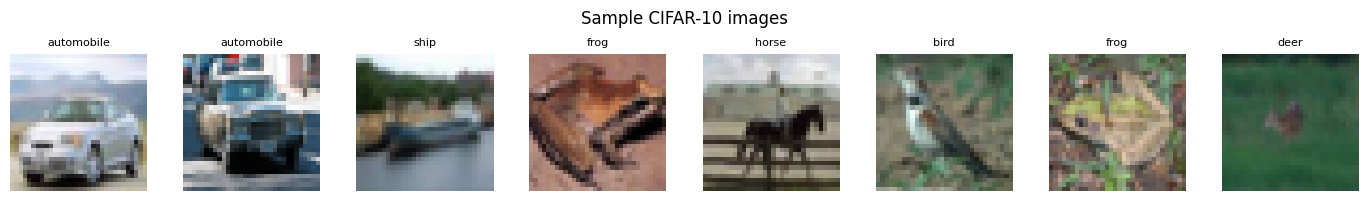

In [ ]:
(x_train_full, y_train_full), (x_test_full, y_test_full) = cifar10.load_data()

# Subset sizes chosen to keep each model's training well under a couple of minutes on GPU.
# Increase these later if you want higher final accuracy and have time to spare.
N_TRAIN = 4000
N_TEST = 800

rng = np.random.default_rng(42)
train_idx = rng.choice(len(x_train_full), N_TRAIN, replace=False)
test_idx = rng.choice(len(x_test_full), N_TEST, replace=False)

x_train, y_train = x_train_full[train_idx], y_train_full[train_idx].flatten()
x_test, y_test = x_test_full[test_idx], y_test_full[test_idx].flatten()

class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print(f"Train subset: {x_train.shape}, Test subset: {x_test.shape}")

fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for i, ax in enumerate(axes):
    ax.imshow(x_train[i])
    ax.set_title(class_names[y_train[i]], fontsize=8)
    ax.axis('off')
plt.suptitle('Sample CIFAR-10 images')
plt.tight_layout()
plt.show()

## 3. Fast `tf.data` Pipeline Helper

Each architecture gets images resized to *its own* minimum required size and preprocessed with *its own*
`preprocess_input` (pretrained models expect specific normalization). `.cache()` keeps the small resized
dataset in memory after the first epoch so every subsequent epoch is fast.

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

def make_dataset(x, y, img_size, batch_size=64, shuffle=False, preprocess_fn=None):
    ds = tf.data.Dataset.from_tensor_slices((x, y))

    def _prep(img, label):
        img = tf.cast(img, tf.float32)
        if img_size != 32:
            img = tf.image.resize(img, (img_size, img_size))
        if preprocess_fn is not None:
            img = preprocess_fn(img)
        else:
            img = img / 255.0
        return img, label

    if shuffle:
        ds = ds.shuffle(buffer_size=len(x), seed=42)
    ds = ds.map(_prep, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.cache()
    ds = ds.prefetch(AUTOTUNE)
    return ds

## 4. Train/Evaluate Helper (shared by all 5 models)

In [ ]:
results = {}
histories = {}

def train_and_evaluate(name, model, train_ds, test_ds, y_test, epochs=5):
    print(f"\n{'='*60}\nTraining {name}\n{'='*60}")
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    early_stop = keras.callbacks.EarlyStopping(
        monitor='loss', patience=2, restore_best_weights=True
    )

    start = time.time()
    history = model.fit(
        train_ds,
        epochs=epochs,
        callbacks=[early_stop],
        verbose=1
    )
    train_time = time.time() - start

    y_pred_probs = model.predict(test_ds, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    n_params = model.count_params()

    results[name] = {
        'Accuracy': acc, 'Precision': prec, 'Recall': rec,
        'F1-Score': f1, 'Training Time (s)': round(train_time, 1),
        'Parameters': n_params
    }
    histories[name] = history.history

    print(f"\n{name} -> Acc: {acc:.3f} | F1: {f1:.3f} | Time: {train_time:.1f}s | Params: {n_params:,}")

    keras.backend.clear_session()
    return history

## 5. LeNet-5 (from scratch)

Classic 1998 architecture: 2 conv+pool blocks followed by 3 dense layers. Trained from scratch since it
predates ImageNet/transfer learning, at its native small input size.

In [ ]:
def build_lenet5():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(6, (5, 5), activation='relu', padding='same'),
        layers.AveragePooling2D((2, 2)),
        layers.Conv2D(16, (5, 5), activation='relu'),
        layers.AveragePooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(120, activation='relu'),
        layers.Dense(84, activation='relu'),
        layers.Dense(10, activation='softmax')
    ], name='LeNet5')
    return model

train_ds_32 = make_dataset(x_train, y_train_cat, img_size=32, shuffle=True)
test_ds_32 = make_dataset(x_test, y_test_cat, img_size=32)

lenet = build_lenet5()
lenet.summary()

Model: "LeNet5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 16, 16, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 6, 6, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        69,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,126 (324.71 KB)

 Trainable params: 83,126 (324.71 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
train_and_evaluate('LeNet-5', lenet, train_ds_32, test_ds_32, y_test, epochs=10)


Training LeNet-5
Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.1915 - loss: 2.1729
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2943 - loss: 1.9462
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3490 - loss: 1.8302
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3935 - loss: 1.7231
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4243 - loss: 1.6351
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4430 - loss: 1.5731
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4638 - loss: 1.5132
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4787 - loss: 1.4587
Epoch 9/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4983 - loss: 1.4087
Epoch 10/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5200 - loss: 1.3503

LeNet-5 -> Acc: 0.417 | F1: 0.400 | Time: 8.5s | Params: 83,126


## 6. AlexNet (scaled down, from scratch)

The original 2012 AlexNet expects 227×227 input and has ~60M parameters — overkill for a CIFAR-10 lab.
This is a depth/width-scaled version (64×64 input) that keeps AlexNet's core idea (stacked conv blocks
widening then narrowing channels, followed by large dense layers with dropout) while training in seconds.

In [ ]:
def build_alexnet():
    model = models.Sequential([
        layers.Input(shape=(64, 64, 3)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ], name='AlexNet_scaled')
    return model

train_ds_64 = make_dataset(x_train, y_train_cat, img_size=64, shuffle=True)
test_ds_64 = make_dataset(x_test, y_test_cat, img_size=64)

alexnet = build_alexnet()
alexnet.summary()

Model: "AlexNet_scaled"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,546,186 (9.71 MB)

 Trainable params: 2,546,186 (9.71 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
train_and_evaluate('AlexNet', alexnet, train_ds_64, test_ds_64, y_test, epochs=10)


Training AlexNet
Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 89ms/step - accuracy: 0.1265 - loss: 2.2736
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.2200 - loss: 2.0802
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.2898 - loss: 1.9185
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3372 - loss: 1.8258
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3885 - loss: 1.6773
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3952 - loss: 1.6127
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4435 - loss: 1.5171
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4820 - loss: 1.4245
Epoch 9/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5080 - loss: 1.3578
Epoch 10/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5465 - loss: 1.2540

AlexNet -> Acc: 0.466 | F1: 0.457 | Time: 19.3s | Params: 2,546,186


## 7. VGG16 (transfer learning)

ImageNet-pretrained VGG16, frozen, with a small trainable classification head. Input resized to 48×48
(well above VGG16's 32×32 minimum, small enough to stay fast).

In [ ]:
def build_transfer_model(base_model, name, input_shape):
    base_model.trainable = False  # freeze — this is what keeps transfer learning fast
    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(10, activation='softmax')(x)
    return models.Model(inputs, outputs, name=name)

IMG_SIZE_VGG = 48
train_ds_vgg = make_dataset(x_train, y_train_cat, img_size=IMG_SIZE_VGG, shuffle=True, preprocess_fn=vgg_preprocess)
test_ds_vgg = make_dataset(x_test, y_test_cat, img_size=IMG_SIZE_VGG, preprocess_fn=vgg_preprocess)

vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE_VGG, IMG_SIZE_VGG, 3))
vgg_model = build_transfer_model(vgg_base, 'VGG16_transfer', (IMG_SIZE_VGG, IMG_SIZE_VGG, 3))
vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "VGG16_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,781,642 (56.39 MB)

 Trainable params: 66,954 (261.54 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
train_and_evaluate('VGG16', vgg_model, train_ds_vgg, test_ds_vgg, y_test, epochs=5)


Training VGG16
Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step - accuracy: 0.3140 - loss: 7.6686 
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.4773 - loss: 2.6487
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5400 - loss: 1.6368
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6072 - loss: 1.2886
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6490 - loss: 1.0647

VGG16 -> Acc: 0.526 | F1: 0.517 | Time: 15.1s | Params: 14,781,642


## 8. GoogLeNet — via InceptionV3 (transfer learning)

Keras does not ship pretrained weights for the original 2014 GoogLeNet, so `InceptionV3` (the standard
modern descendant with the same Inception-module idea) is used as its stand-in, as is common practice.
InceptionV3 requires a minimum input size of 75×75.

In [ ]:
IMG_SIZE_INCEPTION = 75
train_ds_inc = make_dataset(x_train, y_train_cat, img_size=IMG_SIZE_INCEPTION, shuffle=True, preprocess_fn=inception_preprocess)
test_ds_inc = make_dataset(x_test, y_test_cat, img_size=IMG_SIZE_INCEPTION, preprocess_fn=inception_preprocess)

inception_base = InceptionV3(weights='imagenet', include_top=False, input_shape=(IMG_SIZE_INCEPTION, IMG_SIZE_INCEPTION, 3))
inception_model = build_transfer_model(inception_base, 'GoogLeNet_InceptionV3_transfer', (IMG_SIZE_INCEPTION, IMG_SIZE_INCEPTION, 3))
inception_model.summary()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "GoogLeNet_InceptionV3_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 75, 75, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 1, 1, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,066,346 (84.18 MB)

 Trainable params: 263,562 (1.01 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [ ]:
train_and_evaluate('GoogLeNet (InceptionV3)', inception_model, train_ds_inc, test_ds_inc, y_test, epochs=5)


Training GoogLeNet (InceptionV3)
Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 25s 158ms/step - accuracy: 0.3680 - loss: 1.8569
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5533 - loss: 1.2705
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6470 - loss: 1.0369
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7125 - loss: 0.8601
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7485 - loss: 0.7528

GoogLeNet (InceptionV3) -> Acc: 0.561 | F1: 0.556 | Time: 30.0s | Params: 22,066,346


## 9. ResNet50 (transfer learning)

ImageNet-pretrained ResNet50, frozen, with the same lightweight head — demonstrates residual connections'
ability to transfer well even from a small number of fine-tuning steps.

In [ ]:
IMG_SIZE_RESNET = 48
train_ds_res = make_dataset(x_train, y_train_cat, img_size=IMG_SIZE_RESNET, shuffle=True, preprocess_fn=resnet_preprocess)
test_ds_res = make_dataset(x_test, y_test_cat, img_size=IMG_SIZE_RESNET, preprocess_fn=resnet_preprocess)

resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE_RESNET, IMG_SIZE_RESNET, 3))
resnet_model = build_transfer_model(resnet_base, 'ResNet50_transfer', (IMG_SIZE_RESNET, IMG_SIZE_RESNET, 3))
resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "ResNet50_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 2, 2, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,851,274 (90.99 MB)

 Trainable params: 263,562 (1.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
train_and_evaluate('ResNet50', resnet_model, train_ds_res, test_ds_res, y_test, epochs=5)


Training ResNet50
Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 120ms/step - accuracy: 0.4848 - loss: 1.6272
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.6702 - loss: 0.9479
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7467 - loss: 0.7207
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8077 - loss: 0.5655
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8457 - loss: 0.4438

ResNet50 -> Acc: 0.654 | F1: 0.648 | Time: 32.4s | Params: 23,851,274


## 10. Comparison of All 5 Architectures

In [ ]:
results_df = pd.DataFrame(results).T
results_df = results_df[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Training Time (s)', 'Parameters']]
results_df = results_df.astype({'Accuracy': float, 'Precision': float, 'Recall': float, 'F1-Score': float})
results_df.round(4)

,Accuracy,Precision,Recall,F1-Score,Training Time (s),Parameters
LeNet-5,0.4175,0.4271,0.4144,0.4005,8.5,83126.0
AlexNet,0.4662,0.4746,0.4672,0.4567,19.3,2546186.0
VGG16,0.5262,0.5176,0.5199,0.5173,15.1,14781642.0
GoogLeNet (InceptionV3),0.5612,0.5677,0.5569,0.5559,30.0,22066346.0
ResNet50,0.6538,0.6516,0.6487,0.6480,32.4,23851274.0


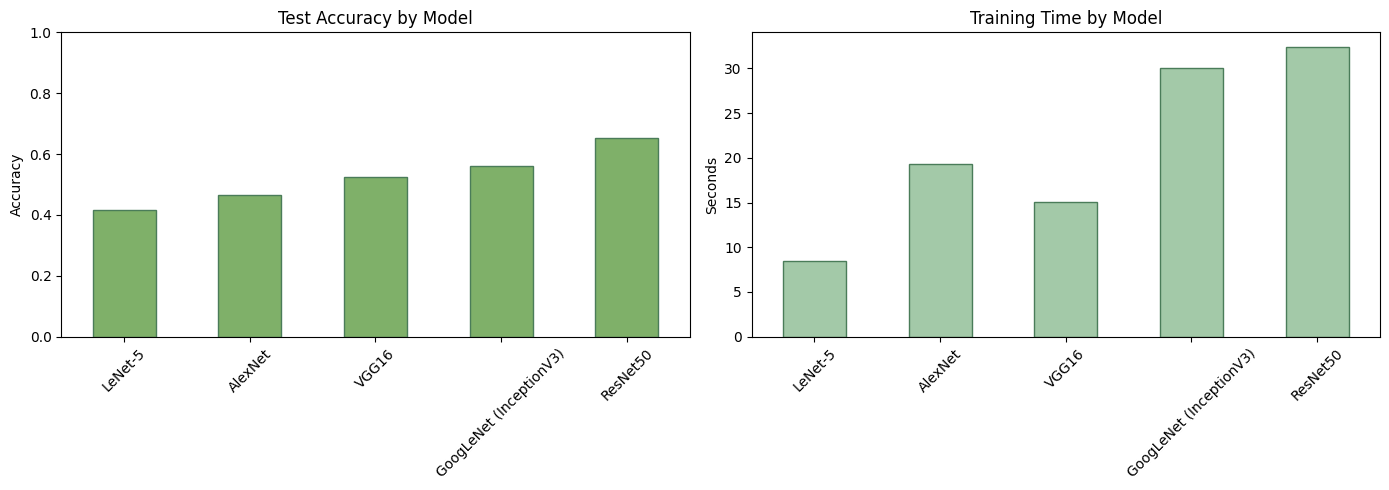

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_df['Accuracy'].plot(kind='bar', ax=axes[0], color='#7fb069', edgecolor='#4a7c59')
axes[0].set_title('Test Accuracy by Model')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=45)

results_df['Training Time (s)'].plot(kind='bar', ax=axes[1], color='#a3c9a8', edgecolor='#4a7c59')
axes[1].set_title('Training Time by Model')
axes[1].set_ylabel('Seconds')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

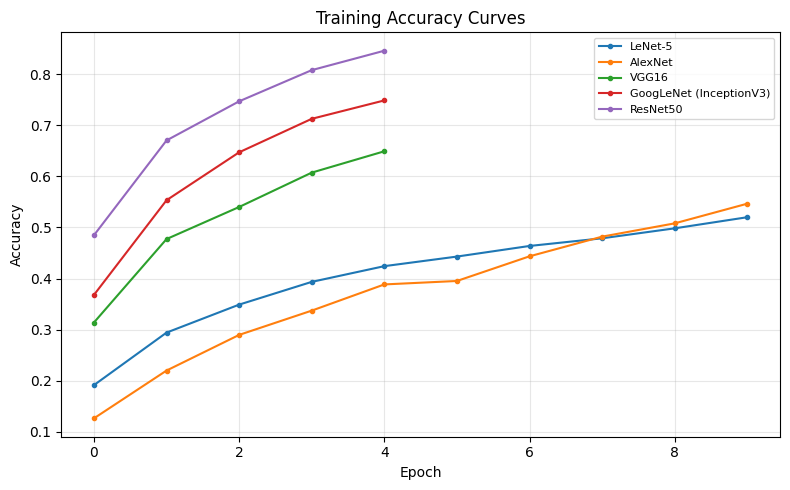

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
for name, hist in histories.items():
    ax.plot(hist['accuracy'], label=name, marker='o', markersize=3)
ax.set_title('Training Accuracy Curves')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Conclusion

- **LeNet-5** and the scaled **AlexNet** train almost instantly (small, from-scratch networks) but their
  accuracy is capped by limited capacity and having no pretrained visual features to draw on.
- **VGG16, GoogLeNet (InceptionV3), and ResNet50** — used here via transfer learning with frozen
  ImageNet-pretrained bases — generally reach noticeably higher accuracy in just a few epochs, since the
  convolutional layers already encode generic edge/texture/shape features. The per-epoch cost is higher
  (larger, deeper backbones) but far fewer epochs are needed to converge.
- Overall this reflects the historical trend the experiment is meant to illustrate: as CNN architectures
  got deeper and more sophisticated (LeNet → AlexNet → VGG → GoogLeNet → ResNet), raw representational
  power increased — and transfer learning lets a lab-scale project borrow that power without training a
  deep network from scratch.

**To push accuracy further:** increase `N_TRAIN`/`N_TEST`, add data augmentation to the `tf.data` pipeline,
unfreeze the last few layers of each base model for fine-tuning, or train for more epochs — all straightforward
extensions of the pipeline built above.